# Relative L² Error: SA‑PINN‑DivType vs. Kurganov–Tadmor
### Compares the divergence‑type PINN predictions with the converged KT solution.

KT data: t = 0.0..20.0,  Nt=201, Nx=1000
Relative L²(n) over spacetime = 7.609989e-03
Relative L²(q) over spacetime = 3.019164e-01
[saved] ./L2_results_DivType.txt


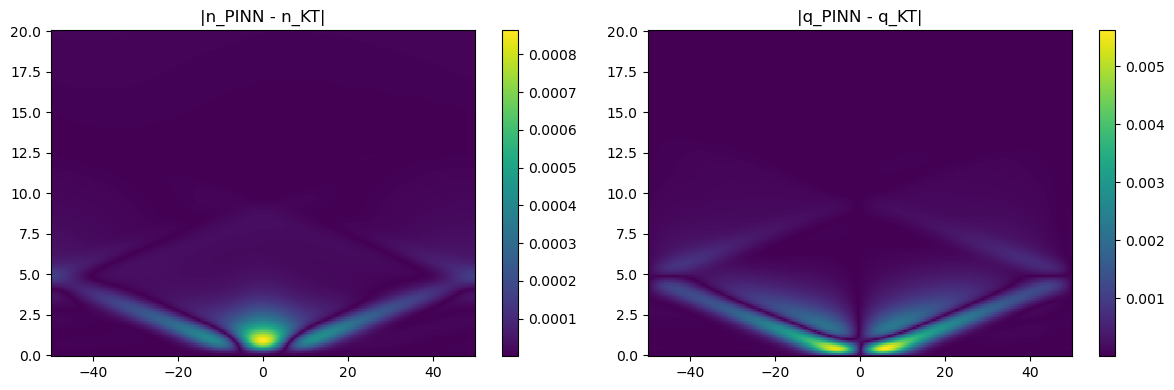

In [6]:
# [imports and parameters]
import numpy as np
import torch
import matplotlib.pyplot as plt
import os, sys

# Add the path to your PINN scripts if needed
# sys.path.append("./")

from SA_PINN_DivType import PINN_DivType
from DivType_Functions import T_func, n_from_alpha_func

# ---------- load KT data ----------
kt_data = np.load("./KT_DivType/snapshots.npz")
t_kt = kt_data["t"]
x_kt = kt_data["x"]
n_kt = kt_data["n"]
q_kt = kt_data["q"]
alpha_kt = kt_data["alpha"]

Nt_kt, Nx_kt = n_kt.shape
print(f"KT data: t = {t_kt[0]:.1f}..{t_kt[-1]:.1f},  "
      f"Nt={Nt_kt}, Nx={Nx_kt}")

# ---------- load PINN data (evaluation grid) ----------
# Replace with the path to your PINN results

# The rest of the L² notebook can then use these arrays directly.
# If you prefer to recompute n, you can still use alpha_pinn_grid and T_func.
pinn_data = np.load("./pinn_runs/divtype_pinn_20260511_021811.npz", allow_pickle=True)
t_pinn = pinn_data["t_eval"]
x_pinn = pinn_data["x_eval"]
q_pinn_grid  = pinn_data["q"]        # corresponds to scriptJ_grid earlier
alpha_pinn_grid = pinn_data["alpha"]
n_pinn_grid = pinn_data["n"]         # already computed, so we can skip recomputing

# Compute n on the PINN grid
from BDNK_IS_Functions import n_from_alpha_func as n_from_alpha_func_t
TT, XX = np.meshgrid(t_pinn, x_pinn, indexing='ij')
TT_t = torch.tensor(TT, dtype=torch.float32)
XX_t = torch.tensor(XX, dtype=torch.float32)
alpha_t = torch.tensor(alpha_pinn_grid, dtype=torch.float32)
T_t = T_func(TT_t, XX_t)
n_pinn = n_from_alpha_func_t(alpha_t, T_t).cpu().numpy()

# ---------- interpolate PINN → KT grid ----------
from scipy.interpolate import RegularGridInterpolator

# The PINN evaluation grid may have a different resolution; interpolate.
interp_n = RegularGridInterpolator((t_kt, x_kt), n_kt)
interp_q = RegularGridInterpolator((t_kt, x_kt), q_kt)

# PINN predictions on the KT grid (spacetime points)
TT_kt, XX_kt = np.meshgrid(t_kt, x_kt, indexing='ij')
# For the PINN, we evaluate at the same points
t_pinn_eval = t_kt if len(t_pinn) == len(t_kt) else np.linspace(t_kt[0], t_kt[-1], len(t_kt))
x_pinn_eval = x_kt if len(x_pinn) == len(x_kt) else np.linspace(x_kt[0], x_kt[-1], len(x_kt))

# Use a quick 2D interpolation if grids differ
from scipy.interpolate import interp2d
f_n_pinn = RegularGridInterpolator((t_pinn, x_pinn), n_pinn)
f_q_pinn = RegularGridInterpolator((t_pinn, x_pinn), q_pinn_grid)

TX = np.stack([TT_kt.ravel(), XX_kt.ravel()], axis=1)
n_pinn_on_kt = f_n_pinn(TX).reshape(Nt_kt, Nx_kt)
q_pinn_on_kt = f_q_pinn(TX).reshape(Nt_kt, Nx_kt)

# ---------- relative L² error ----------
def relative_L2(u_pinn, u_kt):
    num = np.sqrt(np.sum((u_pinn - u_kt)**2))
    den = np.sqrt(np.sum(u_kt**2))
    return num / den

err_n = relative_L2(n_pinn_on_kt, n_kt)
err_q = relative_L2(q_pinn_on_kt, q_kt)

print(f"Relative L²(n) over spacetime = {err_n:.6e}")
print(f"Relative L²(q) over spacetime = {err_q:.6e}")

# ---------- save ----------
save_path = "./L2_results_DivType.txt"
with open(save_path, "w") as f:
    f.write(f"Relative L2(n) = {err_n:.6e}\n")
    f.write(f"Relative L2(q) = {err_q:.6e}\n")
print(f"[saved] {save_path}")

# ---------- quick difference map ----------
fig, axs = plt.subplots(1, 2, figsize=(12,4))
im0 = axs[0].pcolormesh(x_kt, t_kt, np.abs(n_pinn_on_kt - n_kt), shading='auto')
plt.colorbar(im0, ax=axs[0]); axs[0].set_title('|n_PINN - n_KT|')
im1 = axs[1].pcolormesh(x_kt, t_kt, np.abs(q_pinn_on_kt - q_kt), shading='auto')
plt.colorbar(im1, ax=axs[1]); axs[1].set_title('|q_PINN - q_KT|')
plt.tight_layout(); plt.show()